<a href="https://colab.research.google.com/github/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/blob/main/Notebooks/MVP_Machine_Learning_Previsao_Ocorrencias_Criminais_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics  
## Previsão de Vítimas por Tipo Criminal no Brasil em 2026

**Aluno:** Marcelo Alexandre Machado Silvestre  
**Dataset:** Base de Dados e Notas Metodológicas dos Gestores Estaduais — SINESP  
**Tipo de problema:** Regressão com características de Séries Temporais / Forecasting

# 1. Definição do problema

## 1.1 Descrição do problema

A segurança pública é um dos principais desafios enfrentados pelos gestores públicos brasileiros. O acompanhamento dos indicadores criminais permite compreender o comportamento da criminalidade ao longo do tempo, identificar tendências e subsidiar a formulação de políticas públicas voltadas à prevenção e ao combate dos diversos tipos de crimes.

Neste contexto, a disponibilidade de bases históricas de dados possibilita a aplicação de técnicas de Ciência de Dados e Machine Learning para identificar padrões temporais e realizar previsões sobre a evolução dos indicadores criminais. Essas previsões podem auxiliar órgãos de segurança pública no planejamento operacional, na alocação de recursos e na definição de estratégias de atuação.

O presente trabalho utiliza dados do Sistema Nacional de Informações de Segurança Pública (SINESP), abrangendo o período de janeiro de 2020 a dezembro de 2025. Os dados foram agregados por tipo criminal e período mensal, permitindo a construção de uma série histórica contendo a quantidade de vítimas registradas para cada ocorrência criminal.

O objetivo deste MVP é desenvolver e avaliar modelos de Machine Learning capazes de prever a quantidade mensal de vítimas para cada tipo criminal no Brasil durante o ano de 2026, utilizando como base os padrões observados nos anos anteriores.

A solução proposta pode ser utilizada por gestores de segurança pública, analistas de inteligência, pesquisadores e órgãos governamentais interessados em compreender tendências criminais e apoiar processos de tomada de decisão baseados em evidências.

A relevância deste problema está na possibilidade de antecipar cenários futuros, permitindo ações preventivas mais eficientes, melhor distribuição de recursos humanos e materiais, além do aprimoramento das estratégias de monitoramento e enfrentamento da criminalidade.

## 1.2 Objetivo do MVP

Construir e comparar diferentes algoritmos de regressão capazes de estimar a quantidade mensal de vítimas para cada tipo criminal em períodos futuros, identificando o modelo que apresenta melhor desempenho preditivo sobre dados não utilizados durante o treinamento.

Para isso, serão avaliados um modelo baseline e modelos supervisionados de Machine Learning, utilizando métricas apropriadas para problemas de regressão.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão com características de Séries Temporais / Forecasting.

**Justificativa:**  
O objetivo deste trabalho é prever a quantidade mensal de vítimas para cada tipo criminal ao longo do ano de 2026. Como a variável alvo (`total_vitima`) é numérica e representa uma contagem, o problema é caracterizado principalmente como uma tarefa de regressão.

Além disso, os dados possuem estrutura temporal, pois estão organizados mensalmente entre 2020 e 2025. Por essa razão, a modelagem também possui características de séries temporais / forecasting, exigindo que a divisão entre treino e teste respeite a ordem cronológica dos registros.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Hipóteses iniciais

**Hipótese 1:** Os dados históricos mensais de 2020 a 2025 contêm padrões temporais suficientes para apoiar a previsão da quantidade de vítimas por tipo criminal em 2026.

**Hipótese 2:** A variável `data_mes` pode contribuir para capturar efeitos de sazonalidade, já que determinados tipos criminais podem apresentar variações ao longo dos meses do ano.

**Hipótese 3:** Modelos de Machine Learning supervisionado podem apresentar desempenho superior a um modelo baseline simples, como a repetição do valor observado no mesmo mês do ano anterior.

### Critérios de sucesso

**Métrica principal:** RMSE (*Root Mean Squared Error*), pois penaliza erros maiores e é adequada para avaliar previsões numéricas de quantidade de vítimas.

**Métricas complementares:** MAE (*Mean Absolute Error*) e R².

**Resultado mínimo esperado:** O MVP será considerado bem-sucedido caso pelo menos um dos modelos de Machine Learning apresente desempenho superior ao baseline, reduzindo o RMSE em pelo menos 10% no conjunto de teste.

**Restrição prática:** O modelo deve ter baixo custo computacional, ser executável em ambiente Google Colab e manter nível razoável de interpretabilidade.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as bibliotecas utilizadas, a configuração de semente aleatória e informações básicas do ambiente de execução.

In [1]:
# Bibliotecas gerais
import sys
import time
import random
import warnings

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# Pré-processamento e pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Otimização e validação
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações gerais
warnings.filterwarnings("ignore")

# Semente fixa para reprodutibilidade
SEMENTE = 42
np.random.seed(SEMENTE)
random.seed(SEMENTE)

print("Versão do Python:", sys.version.split()[0])
print("Semente utilizada:", SEMENTE)

Versão do Python: 3.12.13
Semente utilizada: 42


## 2.1 Dependências adicionais

Não foram instaladas bibliotecas adicionais. O objetivo foi manter o notebook simples, reprodutível e executável diretamente no Google Colab.

In [2]:
# Nenhuma dependência externa adicional é necessária.
# O notebook utiliza bibliotecas já disponíveis no ambiente padrão do Google Colab.

## 2.2 Funções auxiliares

As funções abaixo foram criadas para evitar repetição de código e padronizar a avaliação dos modelos. Os nomes foram definidos especificamente para este MVP.

In [3]:
def medir_desempenho_regressao(valores_reais, valores_previstos):
    """
    Calcula métricas de avaliação para modelos de regressão.

    Parâmetros:
    valores_reais: valores observados no conjunto de teste.
    valores_previstos: valores estimados pelo modelo.

    Retorna:
    Dicionário com MAE, RMSE e R².
    """

    erro_quadratico_medio = mean_squared_error(
        valores_reais,
        valores_previstos
    )

    return {
        "MAE": mean_absolute_error(valores_reais, valores_previstos),
        "RMSE": np.sqrt(erro_quadratico_medio),
        "R2": r2_score(valores_reais, valores_previstos)
    }


def montar_quadro_comparativo(dic_resultados):
    """
    Organiza os resultados dos modelos em tabela ordenada pelo RMSE.
    """

    tabela = pd.DataFrame(dic_resultados).T
    tabela = tabela.sort_values("RMSE")

    return tabela


def calcular_reducao_percentual(valor_referencia, valor_modelo):
    """
    Calcula a redução percentual de erro em relação ao baseline.
    """

    return ((valor_referencia - valor_modelo) / valor_referencia) * 100

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste MVP foi obtido a partir das bases públicas disponibilizadas pelo **Sistema Nacional de Informações de Segurança Pública (SINESP)**, mantido pelo Ministério da Justiça e Segurança Pública.

**Nome do dataset:**  
Base de Dados e Notas Metodológicas dos Gestores Estaduais do Sistema Nacional de Informações de Segurança Pública — SINESP.

**Fonte:**  
https://www.gov.br/mj/pt-br/assuntos/sua-seguranca/seguranca-publica/estatistica/dados-nacionais-1

Foram utilizadas bases anuais referentes ao período de **2020 a 2025**, contendo registros mensais de indicadores criminais informados pelas unidades federativas brasileiras.

A escolha dessa base se justifica por sua abrangência nacional, por sua origem oficial e pela possibilidade de construção de uma série histórica mensal por tipo criminal. Como o objetivo do MVP é prever a quantidade mensal de vítimas em 2026, os dados do SINESP são adequados para um problema de regressão com características temporais.

Como restrição metodológica, foram considerados apenas registros com `total_vitima > 0`, pois o foco do trabalho é prever a quantidade de vítimas associadas aos tipos criminais.

Sob o ponto de vista ético, os dados são públicos, agregados e não identificam pessoas individualmente. Portanto, não há tratamento de dados pessoais sensíveis ou informações confidenciais neste MVP.

Os arquivos são carregados diretamente no notebook por meio de URLs públicas, sem upload manual e sem dependência de arquivos locais.

## 3.2 Carga dos dados

As bases anuais são carregadas diretamente do GitHub em formato CSV. Em seguida, são concatenadas em um único dataframe.

In [4]:
# URLs públicas dos arquivos CSV no GitHub.
# As URLs usam o formato RAW para permitir leitura direta pelo pandas.

url_base_2020 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2020.csv"
url_base_2021 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2021.csv"
url_base_2022 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2022.csv"
url_base_2023 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2023.csv"
url_base_2024 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2024.csv"
url_base_2025 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2025.csv"

# Leitura dos arquivos anuais.
base_2020 = pd.read_csv(url_base_2020, sep=";", low_memory=False)
base_2021 = pd.read_csv(url_base_2021, sep=";", low_memory=False)
base_2022 = pd.read_csv(url_base_2022, sep=";", low_memory=False)
base_2023 = pd.read_csv(url_base_2023, sep=";", low_memory=False)
base_2024 = pd.read_csv(url_base_2024, sep=";", low_memory=False)
base_2025 = pd.read_csv(url_base_2025, sep=";", low_memory=False)

# Consolidação das bases em um único dataframe.
dados_brutos = pd.concat(
    [
        base_2020,
        base_2021,
        base_2022,
        base_2023,
        base_2024,
        base_2025
    ],
    ignore_index=True
)

# Visão técnica inicial da base consolidada.
dados_brutos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654995 entries, 0 to 4654994
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   uf               object 
 1   municipio        object 
 2   evento           object 
 3   data_referencia  object 
 4   agente           object 
 5   arma             object 
 6   faixa_etaria     object 
 7   feminino         float64
 8   masculino        float64
 9   nao_informado    float64
 10  total_vitima     float64
 11  total            float64
 12  total_peso       float64
 13  abrangencia      object 
dtypes: float64(6), object(8)
memory usage: 497.2+ MB


## 3.3 Construção da base de trabalho

A base original contém variáveis referentes a diferentes tipos de indicadores. Como este MVP busca prever vítimas, foram selecionadas as colunas diretamente relacionadas à contagem de vítimas por tipo criminal.

In [5]:
# Cópia da base consolidada para preservar os dados brutos.
dados_vitimas = dados_brutos.copy()

# Conversão da coluna de data.
# dayfirst=True é usado porque a base brasileira pode estar no padrão dia/mês/ano.
dados_vitimas["data_referencia"] = pd.to_datetime(
    dados_vitimas["data_referencia"],
    dayfirst=True,
    errors="coerce"
)

# Seleção de registros com vítimas e das colunas necessárias ao MVP.
dados_vitimas = dados_vitimas.loc[
    dados_vitimas["total_vitima"] > 0,
    [
        "uf",
        "evento",
        "data_referencia",
        "feminino",
        "masculino",
        "nao_informado",
        "total_vitima"
    ]
].copy()

# Extração de mês e ano a partir da data de referência.
posicao_data = dados_vitimas.columns.get_loc("data_referencia")

dados_vitimas.insert(
    posicao_data + 1,
    "data_mes",
    dados_vitimas["data_referencia"].dt.month
)

dados_vitimas.insert(
    posicao_data + 2,
    "data_ano",
    dados_vitimas["data_referencia"].dt.year
)

# Agregação por UF, tipo criminal e período mensal.
# Essa etapa elimina granularidades desnecessárias e organiza os dados para modelagem temporal.
dados_vitimas = (
    dados_vitimas
    .groupby(
        [
            "uf",
            "evento",
            "data_referencia",
            "data_mes",
            "data_ano"
        ],
        as_index=False
    )
    .agg({
        "feminino": "sum",
        "masculino": "sum",
        "nao_informado": "sum",
        "total_vitima": "sum"
    })
    .sort_values(
        [
            "evento",
            "data_ano",
            "data_mes"
        ]
    )
)

display(dados_vitimas.head())
display(dados_vitimas.tail())

,uf,evento,data_referencia,data_mes,data_ano,feminino,masculino,nao_informado,total_vitima
0,AC,Estupro,2020-01-01,1,2020,12.0,1.0,1.0,14.0
886,AL,Estupro,2020-01-01,1,2020,19.0,0.0,0.0,19.0
1902,AM,Estupro,2020-01-01,1,2020,19.0,1.0,0.0,20.0
2913,AP,Estupro,2020-01-01,1,2020,9.0,1.0,0.0,10.0
3807,BA,Estupro,2020-01-01,1,2020,78.0,7.0,0.0,85.0


,uf,evento,data_referencia,data_mes,data_ano,feminino,masculino,nao_informado,total_vitima
23514,RS,Tentativa de homicídio,2025-12-01,12,2025,26.0,153.0,0.0,179.0
24521,SC,Tentativa de homicídio,2025-12-01,12,2025,24.0,130.0,0.0,154.0
25510,SE,Tentativa de homicídio,2025-12-01,12,2025,8.0,55.0,2.0,65.0
26725,SP,Tentativa de homicídio,2025-12-01,12,2025,66.0,286.0,0.0,352.0
27703,TO,Tentativa de homicídio,2025-12-01,12,2025,4.0,37.0,0.0,41.0


## 3.4 Base nacional para modelagem

Para reduzir a complexidade do MVP, a modelagem será feita em nível nacional, agregando os registros das unidades federativas por tipo criminal, mês e ano.

In [6]:
# Consolidação nacional por tipo criminal, mês e ano.
serie_criminal_brasil = (
    dados_vitimas
    .groupby(
        [
            "evento",
            "data_mes",
            "data_ano"
        ],
        as_index=False
    )["total_vitima"]
    .sum()
    .sort_values(
        [
            "evento",
            "data_ano",
            "data_mes"
        ]
    )
)

# Criação de índice temporal mensal.
# Janeiro de 2020 recebe índice 1 e dezembro de 2025 recebe índice 72.
serie_criminal_brasil["indice_tempo"] = (
    (serie_criminal_brasil["data_ano"] - 2020) * 12
    + serie_criminal_brasil["data_mes"]
)

# Reorganização das colunas para facilitar a leitura.
serie_criminal_brasil = serie_criminal_brasil[
    [
        "evento",
        "data_mes",
        "data_ano",
        "indice_tempo",
        "total_vitima"
    ]
]

display(serie_criminal_brasil.head())
display(serie_criminal_brasil.tail())

,evento,data_mes,data_ano,indice_tempo,total_vitima
0,Estupro,1,2020,1,2217.0
6,Estupro,2,2020,2,2052.0
12,Estupro,3,2020,3,1766.0
18,Estupro,4,2020,4,1423.0
24,Estupro,5,2020,5,1461.0


,evento,data_mes,data_ano,indice_tempo,total_vitima
1199,Tentativa de homicídio,8,2025,68,2967.0
1205,Tentativa de homicídio,9,2025,69,2754.0
1211,Tentativa de homicídio,10,2025,70,2815.0
1217,Tentativa de homicídio,11,2025,71,2820.0
1223,Tentativa de homicídio,12,2025,72,3025.0


## 3.5 Visão geral do dataset

Nesta etapa são verificados formato, tipos de dados, valores ausentes, duplicidades e amostras da base final de modelagem.

In [7]:
print("Dimensão da base final:", serie_criminal_brasil.shape)

print("\nTipos das variáveis:")
display(serie_criminal_brasil.dtypes.to_frame("tipo"))

print("\nQuantidade de valores ausentes:")
display(serie_criminal_brasil.isna().sum().to_frame("ausentes"))

print("\nRegistros duplicados:", serie_criminal_brasil.duplicated().sum())

display(serie_criminal_brasil.sample(5, random_state=SEMENTE))

Dimensão da base final: (1224, 5)

Tipos das variáveis:


,tipo
evento,object
data_mes,int32
data_ano,int32
indice_tempo,int32
total_vitima,float64



Quantidade de valores ausentes:


,ausentes
evento,0
data_mes,0
data_ano,0
indice_tempo,0
total_vitima,0



Registros duplicados: 0


,evento,data_mes,data_ano,indice_tempo,total_vitima
655,Mortes no trânsito,2,2021,14,348.0
240,Homicídio doloso,5,2020,5,3418.0
210,Feminicídio,12,2020,12,133.0
680,Mortes no trânsito,6,2022,30,405.0
933,Roubo seguido de morte (latrocínio),12,2023,48,75.0


## 3.6 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `evento` | Categórica | Tipo criminal registrado | Sim | Identifica o padrão específico de cada crime |
| `data_mes` | Numérica | Mês da ocorrência | Sim | Ajuda a capturar possíveis efeitos sazonais |
| `data_ano` | Numérica | Ano da ocorrência | Sim | Representa a evolução anual |
| `indice_tempo` | Numérica | Índice sequencial mensal | Sim | Representa a ordem cronológica da série |
| `total_vitima` | Numérica | Quantidade mensal de vítimas | Alvo | Valor que será previsto |

# 4. Análise exploratória dos dados

A análise exploratória busca compreender a distribuição da variável alvo, a diferença entre tipos criminais, possíveis padrões temporais e evidências relacionadas às hipóteses iniciais.

## 4.1 Estatísticas descritivas

In [8]:
serie_criminal_brasil.describe()

,data_mes,data_ano,indice_tempo,total_vitima
count,1224.000000,1224.000000,1224.0000,1224.000000
mean,6.500000,2022.500000,36.5000,1704.252451
std,3.453464,1.708523,20.7911,1889.987271
min,1.000000,2020.000000,1.0000,5.000000
25%,3.750000,2021.000000,18.7500,118.750000
50%,6.500000,2022.500000,36.5000,1013.000000
75%,9.250000,2024.000000,54.2500,2943.250000
max,12.000000,2025.000000,72.0000,7578.000000


As estatísticas descritivas permitem observar a amplitude, média e dispersão dos registros mensais.

## 4.2 Distribuição da variável alvo

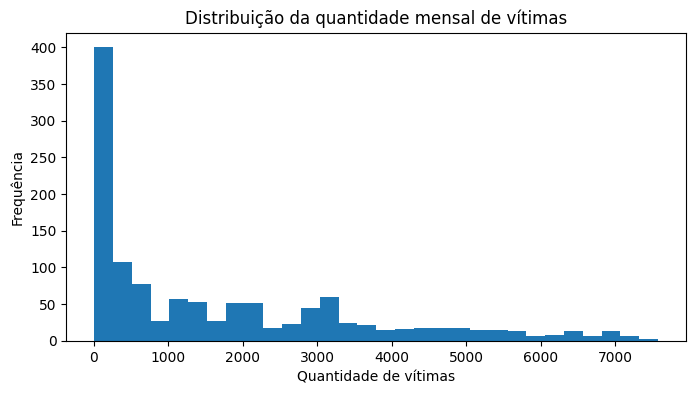

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(serie_criminal_brasil["total_vitima"], bins=30)
plt.title("Distribuição da quantidade mensal de vítimas")
plt.xlabel("Quantidade de vítimas")
plt.ylabel("Frequência")
plt.show()

A distribuição da variável alvo permite identificar concentração de valores, assimetria e valores extremos.

## 4.3 Boxplot da variável alvo

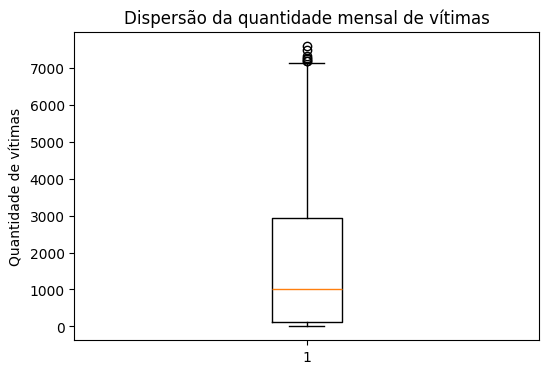

In [10]:
plt.figure(figsize=(6, 4))
plt.boxplot(serie_criminal_brasil["total_vitima"])
plt.title("Dispersão da quantidade mensal de vítimas")
plt.ylabel("Quantidade de vítimas")
plt.show()

O boxplot permite visualizar a dispersão. Valores extremos podem representar crimes mais frequentes e não necessariamente erros.

## 4.4 Quantidade de tipos criminais

In [11]:
total_tipos_criminais = serie_criminal_brasil["evento"].nunique()
print("Quantidade de tipos criminais analisados:", total_tipos_criminais)

Quantidade de tipos criminais analisados: 17


Esta verificação mostra quantos tipos criminais diferentes compõem a base nacional.

## 4.5 Total acumulado de vítimas por tipo criminal

In [12]:
vitimas_por_tipo = (
    serie_criminal_brasil
    .groupby("evento")["total_vitima"]
    .sum()
    .sort_values(ascending=False)
)
display(vitimas_por_tipo.to_frame("total_acumulado_vitimas"))

,total_acumulado_vitimas
evento,
Pessoa Desaparecida,452391.0
Estupro de vulnerável,342687.0
Pessoa Localizada,287811.0
Homicídio doloso,223415.0
Tentativa de homicídio,218198.0
Morte no trânsito ou em decorrência dele (exceto homicídio doloso),145214.0
Estupro,138586.0
Suicídio,93280.0
Mortes a esclarecer (sem indício de crime),71842.0


A soma por tipo criminal permite compreender quais eventos concentram maior volume de vítimas.

## 4.6 Top 10 tipos criminais por volume de vítimas

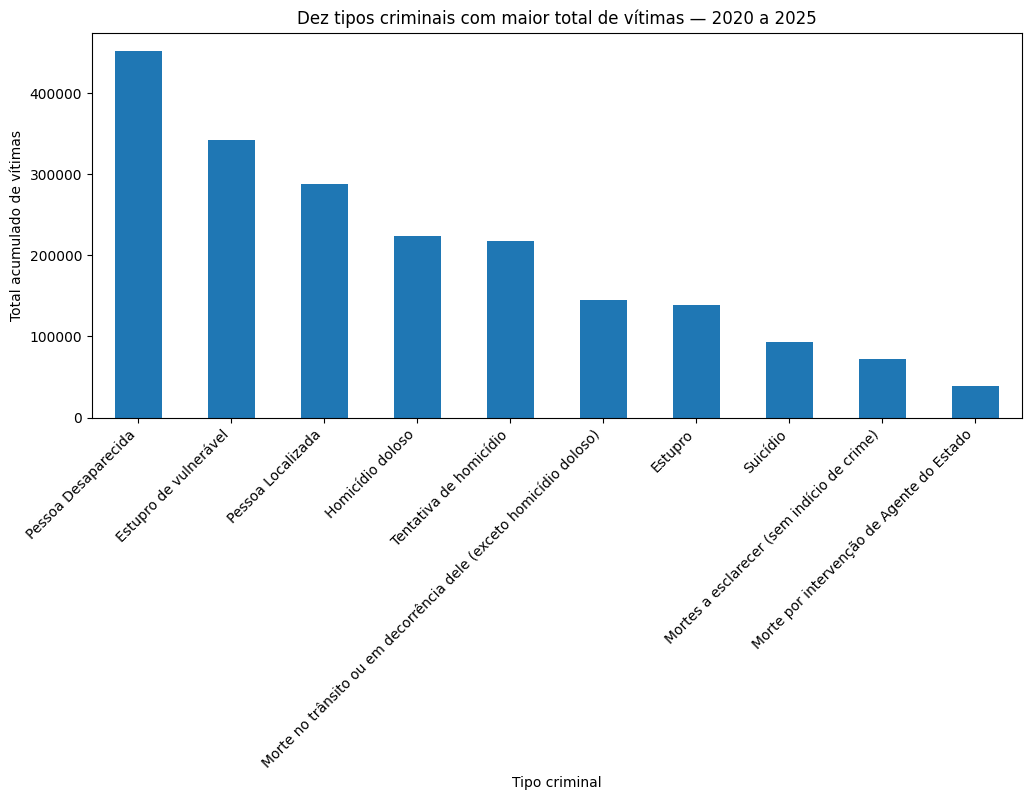

In [13]:
dez_maiores_tipos = vitimas_por_tipo.head(10)
plt.figure(figsize=(12, 5))
dez_maiores_tipos.plot(kind="bar")
plt.title("Dez tipos criminais com maior total de vítimas — 2020 a 2025")
plt.xlabel("Tipo criminal")
plt.ylabel("Total acumulado de vítimas")
plt.xticks(rotation=45, ha="right")
plt.show()

Esse gráfico evidencia que os tipos criminais possuem magnitudes diferentes, reforçando a importância da variável `evento`.

## 4.7 Evolução temporal de um tipo criminal

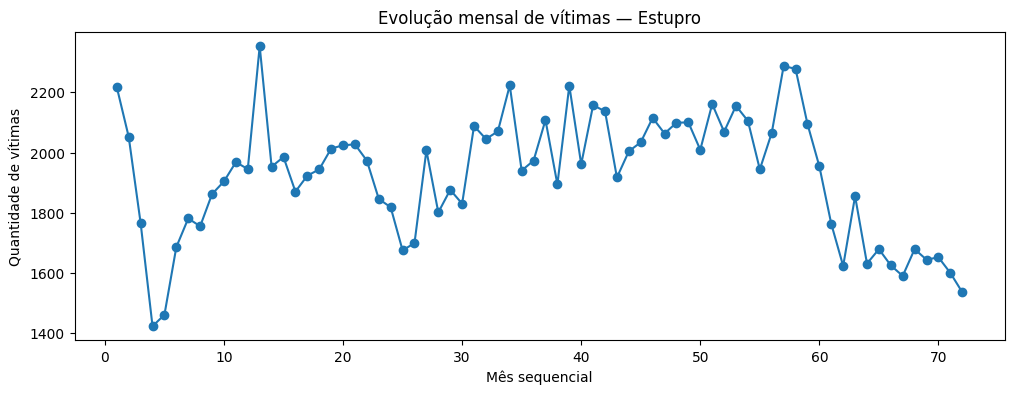

In [14]:
crime_analisado = "Estupro"
serie_crime_especifico = serie_criminal_brasil[
    serie_criminal_brasil["evento"] == crime_analisado
].copy()

plt.figure(figsize=(12, 4))
plt.plot(
    serie_crime_especifico["indice_tempo"],
    serie_crime_especifico["total_vitima"],
    marker="o"
)
plt.title(f"Evolução mensal de vítimas — {crime_analisado}")
plt.xlabel("Mês sequencial")
plt.ylabel("Quantidade de vítimas")
plt.show()

A evolução mensal de um tipo criminal permite observar oscilações, tendência e possíveis padrões sazonais.

## 4.8 Evolução temporal agregada no Brasil

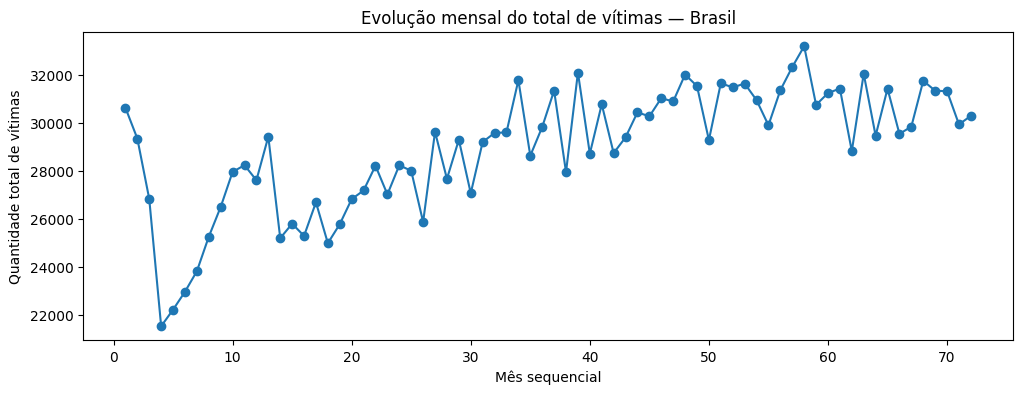

In [15]:
total_mensal_brasil = (
    serie_criminal_brasil
    .groupby(["data_ano", "data_mes", "indice_tempo"], as_index=False)["total_vitima"]
    .sum()
    .sort_values("indice_tempo")
)

plt.figure(figsize=(12, 4))
plt.plot(
    total_mensal_brasil["indice_tempo"],
    total_mensal_brasil["total_vitima"],
    marker="o"
)
plt.title("Evolução mensal do total de vítimas — Brasil")
plt.xlabel("Mês sequencial")
plt.ylabel("Quantidade total de vítimas")
plt.show()

Esse gráfico contribui para a verificação da Hipótese 1, pois mostra se há comportamento temporal estruturado.

## 4.9 Média mensal de vítimas

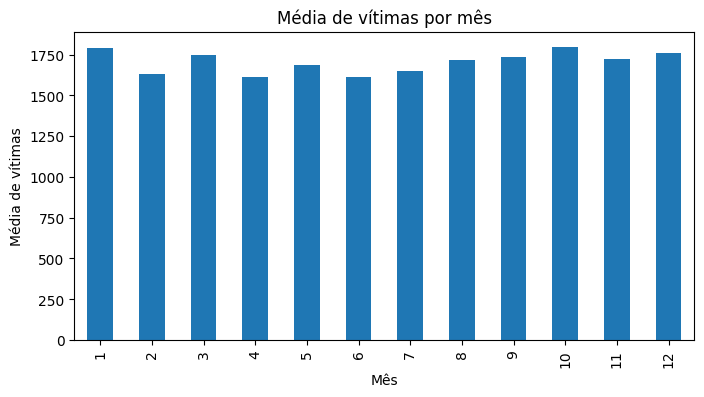

In [16]:
media_mensal_vitimas = (
    serie_criminal_brasil
    .groupby("data_mes")["total_vitima"]
    .mean()
)

plt.figure(figsize=(8, 4))
media_mensal_vitimas.plot(kind="bar")
plt.title("Média de vítimas por mês")
plt.xlabel("Mês")
plt.ylabel("Média de vítimas")
plt.show()

A média por mês está diretamente relacionada à Hipótese 2, pois indica possível sazonalidade.

## 4.10 Síntese da análise exploratória

A análise exploratória indica que a base possui estrutura temporal mensal e contém diferentes tipos criminais com volumes bastante distintos de vítimas. Essa diferença entre eventos reforça a necessidade de manter o tipo criminal como variável explicativa.

A variável `total_vitima` apresenta variação expressiva, comportamento esperado em dados de segurança pública. As análises temporais sugerem que há padrões ao longo do tempo, e a análise por mês indica que a variável `data_mes` pode conter informação útil para capturar possíveis efeitos sazonais.

Não foram identificados valores ausentes ou duplicidades na base final de modelagem. As variáveis `data_mes`, `data_ano` e `indice_tempo` representam a dimensão temporal do problema e serão utilizadas para apoiar a previsão dos valores de 2026.

# 5. Preparação dos dados e divisão treino/teste

Nesta seção são definidos os atributos de entrada, a variável alvo e a estratégia de separação entre treinamento e teste.

## 5.1 Definição de atributos e alvo

In [17]:
coluna_alvo = "total_vitima"

atributos_modelagem = [
    "evento",
    "data_mes",
    "data_ano",
    "indice_tempo"
]

print("Variável alvo:", coluna_alvo)
print("Atributos utilizados:", atributos_modelagem)

Variável alvo: total_vitima
Atributos utilizados: ['evento', 'data_mes', 'data_ano', 'indice_tempo']


## 5.2 Organização temporal dos dados

In [18]:
# Ordenação cronológica da base.
base_modelagem = serie_criminal_brasil.sort_values(
    ["data_ano", "data_mes", "evento"]
).copy()

display(base_modelagem.head())
display(base_modelagem.tail())

,evento,data_mes,data_ano,indice_tempo,total_vitima
0,Estupro,1,2020,1,2217.0
72,Estupro de vulnerável,1,2020,1,4371.0
144,Feminicídio,1,2020,1,98.0
216,Homicídio doloso,1,2020,1,3619.0
288,Lesão corporal seguida de morte,1,2020,1,65.0


,evento,data_mes,data_ano,indice_tempo,total_vitima
935,Roubo seguido de morte (latrocínio),12,2025,72,71.0
1007,Suicídio,12,2025,72,1483.0
1079,Suicídio de Agente do Estado,12,2025,72,12.0
1151,Tentativa de feminicídio,12,2025,72,421.0
1223,Tentativa de homicídio,12,2025,72,3025.0


## 5.3 Divisão treino/teste

In [19]:
# Treinamento com dados de 2020 a 2024.
conjunto_treinamento = base_modelagem[
    base_modelagem["data_ano"] <= 2024
].copy()

# Teste com dados de 2025.
conjunto_teste = base_modelagem[
    base_modelagem["data_ano"] == 2025
].copy()

# Separação entre atributos e variável alvo.
X_treinamento = conjunto_treinamento[atributos_modelagem].copy()
y_treinamento = conjunto_treinamento[coluna_alvo].copy()

X_teste = conjunto_teste[atributos_modelagem].copy()
y_teste = conjunto_teste[coluna_alvo].copy()

print("Formato de X_treinamento:", X_treinamento.shape)
print("Formato de X_teste:", X_teste.shape)

Formato de X_treinamento: (1020, 4)
Formato de X_teste: (204, 4)


## 5.4 Justificativa da divisão

Como o objetivo do MVP é prever valores futuros, a divisão entre treinamento e teste foi feita com base no tempo.

Os dados de 2020 a 2024 foram utilizados para treinar os modelos, enquanto o ano de 2025 foi reservado para avaliação. Essa abordagem simula um cenário real em que dados históricos são usados para prever períodos ainda não observados.

Não foi utilizada divisão aleatória, pois isso poderia misturar registros futuros no treinamento e causar vazamento de informação, prejudicando a validade da avaliação.

# 6. Pré-processamento e pipeline

Nesta etapa são definidas as transformações necessárias para que os atributos possam ser utilizados pelos modelos.

## 6.1 Separação dos tipos de atributos

In [20]:
atributos_quantitativos = [
    "data_mes",
    "data_ano",
    "indice_tempo"
]

atributos_qualitativos = [
    "evento"
]

print("Atributos quantitativos:", atributos_quantitativos)
print("Atributos qualitativos:", atributos_qualitativos)

Atributos quantitativos: ['data_mes', 'data_ano', 'indice_tempo']
Atributos qualitativos: ['evento']


## 6.2 Transformações dos atributos

In [21]:
# Pipeline para variáveis numéricas.
tratamento_quantitativo = Pipeline(
    steps=[
        ("preencher_mediana", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler())
    ]
)

# Pipeline para variáveis categóricas.
tratamento_qualitativo = Pipeline(
    steps=[
        ("preencher_moda", SimpleImputer(strategy="most_frequent")),
        ("codificar_categorias", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combina as transformações em uma única etapa.
etapa_preparacao_atributos = ColumnTransformer(
    transformers=[
        ("variaveis_numericas", tratamento_quantitativo, atributos_quantitativos),
        ("variaveis_categoricas", tratamento_qualitativo, atributos_qualitativos)
    ],
    remainder="drop"
)

## 6.3 Decisões de pré-processamento

A variável `evento` foi transformada por meio de codificação One-Hot, pois representa categorias textuais que precisam ser convertidas para formato numérico antes do treinamento.

As variáveis numéricas foram padronizadas para deixar os atributos em escala comparável. Embora modelos baseados em árvores não dependam dessa transformação, a padronização favorece a comparação com a Regressão Linear.

Foram incluídas etapas de imputação no pipeline para tornar o processo mais robusto. A base final não apresentou valores ausentes relevantes, mas essa prática evita falhas caso algum valor nulo apareça em futuras execuções.

As variáveis utilizadas estariam disponíveis no momento da previsão de 2026: tipo criminal, mês, ano e índice temporal.

# 7. Baseline e modelos candidatos

Nesta seção são definidos o modelo de referência e os modelos supervisionados que serão comparados.

## 7.1 Baseline temporal

In [22]:
# O baseline usa os valores observados em 2024 para prever os mesmos meses de 2025.
referencia_ano_anterior = (
    conjunto_treinamento[conjunto_treinamento["data_ano"] == 2024]
    [["evento", "data_mes", "total_vitima"]]
    .rename(columns={"total_vitima": "previsao_baseline"})
)

avaliacao_baseline = conjunto_teste.merge(
    referencia_ano_anterior,
    on=["evento", "data_mes"],
    how="left"
)

resultado_referencia = medir_desempenho_regressao(
    avaliacao_baseline["total_vitima"],
    avaliacao_baseline["previsao_baseline"]
)

resultado_referencia

{'MAE': 123.73039215686275,
 'RMSE': np.float64(202.0547028435034),
 'R2': 0.9904634150020242}

O baseline adotado repete o valor observado no mesmo mês do ano anterior para o mesmo tipo criminal. Essa estratégia é simples e coerente com problemas temporais.

## 7.2 Modelos candidatos

In [23]:
# Cada modelo é construído com o mesmo pipeline de preparação dos atributos.
modelos_experimentais = {
    "Linear_Tradicional": Pipeline(
        steps=[
            ("preparacao", etapa_preparacao_atributos),
            ("estimador", LinearRegression())
        ]
    ),

    "Floresta_Aleatoria": Pipeline(
        steps=[
            ("preparacao", etapa_preparacao_atributos),
            ("estimador", RandomForestRegressor(
                n_estimators=200,
                random_state=SEMENTE
            ))
        ]
    ),

    "Impulsionamento_Gradiente": Pipeline(
        steps=[
            ("preparacao", etapa_preparacao_atributos),
            ("estimador", GradientBoostingRegressor(
                random_state=SEMENTE
            ))
        ]
    )
}

print("Modelos avaliados:")
print(list(modelos_experimentais.keys()))

Modelos avaliados:
['Linear_Tradicional', 'Floresta_Aleatoria', 'Impulsionamento_Gradiente']


## 7.3 Justificativa dos modelos

A Regressão Linear foi incluída por ser simples, interpretável e útil como referência inicial entre os modelos supervisionados.

A Floresta Aleatória foi escolhida por lidar bem com dados tabulares, capturar interações entre atributos e representar relações não lineares.

O modelo de Impulsionamento por Gradiente foi selecionado por sua capacidade de combinar estimadores sequenciais e reduzir erros progressivamente, sendo uma alternativa robusta para problemas de regressão.

A comparação entre esses modelos e o baseline permite verificar se os algoritmos de Machine Learning conseguem superar uma regra temporal simples.

# 8. Treinamento e avaliação inicial

Nesta etapa, os modelos são treinados com os dados de 2020 a 2024 e avaliados com dados de 2025.

In [24]:
desempenho_inicial = {}
modelos_treinados = {}

# Registro do resultado do baseline.
desempenho_inicial["Referencia_Ano_Anterior"] = resultado_referencia

# Treinamento e avaliação dos modelos candidatos.
for nome_modelo, modelo in modelos_experimentais.items():

    inicio_treino = time.time()

    # Treina o modelo com os dados históricos.
    modelo.fit(X_treinamento, y_treinamento)

    duracao_treino = time.time() - inicio_treino

    # Gera previsões para o ano de 2025.
    previsoes_teste = modelo.predict(X_teste)

    # Calcula métricas de desempenho.
    desempenho_inicial[nome_modelo] = medir_desempenho_regressao(
        y_teste,
        previsoes_teste
    )

    # Registra o tempo de treinamento.
    desempenho_inicial[nome_modelo]["tempo_treino_seg"] = round(duracao_treino, 3)

    # Armazena o modelo treinado.
    modelos_treinados[nome_modelo] = modelo

tabela_desempenho_inicial = montar_quadro_comparativo(desempenho_inicial)
display(tabela_desempenho_inicial)

,MAE,RMSE,R2,tempo_treino_seg
Referencia_Ano_Anterior,123.730392,202.054703,0.990463,NaN
Floresta_Aleatoria,127.112525,204.791373,0.990203,1.599
Impulsionamento_Gradiente,207.445387,274.503477,0.982398,0.143
Linear_Tradicional,357.672740,443.980973,0.953955,0.039


## 8.1 Interpretação dos resultados iniciais

A avaliação inicial compara o baseline com três modelos de regressão. A métrica principal é o RMSE, pois penaliza erros maiores e é adequada para previsões numéricas.

O MAE complementa a análise ao indicar o erro médio absoluto em quantidade de vítimas. O R² mostra a capacidade explicativa do modelo em relação à variação observada no conjunto de teste.

O modelo que apresentar o menor RMSE será considerado o melhor candidato inicial.

# 9. Otimização de hiperparâmetros

Nesta seção é feito o ajuste de hiperparâmetros de um dos modelos candidatos.

## 9.1 Modelo escolhido para ajuste

In [25]:
# A Floresta Aleatória será otimizada por ser robusta para dados tabulares.
modelo_base_floresta = Pipeline(
    steps=[
        ("preparacao", etapa_preparacao_atributos),
        ("estimador", RandomForestRegressor(random_state=SEMENTE))
    ]
)

## 9.2 Busca de hiperparâmetros

In [26]:
# Grade de hiperparâmetros a serem testados.
grade_parametros_floresta = {
    "estimador__n_estimators": [100, 200, 300],
    "estimador__max_depth": [5, 10, None],
    "estimador__min_samples_split": [2, 5],
    "estimador__min_samples_leaf": [1, 2]
}

# Validação temporal para respeitar a ordem cronológica dos dados.
validacao_temporal = TimeSeriesSplit(n_splits=3)

# GridSearchCV busca a melhor combinação de hiperparâmetros segundo o RMSE.
busca_floresta = GridSearchCV(
    estimator=modelo_base_floresta,
    param_grid=grade_parametros_floresta,
    scoring="neg_root_mean_squared_error",
    cv=validacao_temporal,
    n_jobs=-1
)

busca_floresta.fit(X_treinamento, y_treinamento)

print("Melhores hiperparâmetros encontrados:")
print(busca_floresta.best_params_)

Melhores hiperparâmetros encontrados:
{'estimador__max_depth': None, 'estimador__min_samples_leaf': 1, 'estimador__min_samples_split': 5, 'estimador__n_estimators': 300}


## 9.3 Avaliação do modelo ajustado

In [27]:
# Recupera o melhor modelo encontrado pela busca.
floresta_ajustada = busca_floresta.best_estimator_

# Avalia o modelo otimizado no ano de 2025.
previsao_floresta_ajustada = floresta_ajustada.predict(X_teste)

desempenho_inicial["Floresta_Aleatoria_Ajustada"] = medir_desempenho_regressao(
    y_teste,
    previsao_floresta_ajustada
)

tabela_desempenho_final = montar_quadro_comparativo(desempenho_inicial)
display(tabela_desempenho_final)

,MAE,RMSE,R2,tempo_treino_seg
Referencia_Ano_Anterior,123.730392,202.054703,0.990463,NaN
Floresta_Aleatoria,127.112525,204.791373,0.990203,1.599
Floresta_Aleatoria_Ajustada,127.849563,206.116700,0.990076,NaN
Impulsionamento_Gradiente,207.445387,274.503477,0.982398,0.143
Linear_Tradicional,357.672740,443.980973,0.953955,0.039


## 9.4 Comentário sobre a otimização

A etapa de otimização buscou melhorar o desempenho da Floresta Aleatória por meio da seleção de hiperparâmetros. Foi utilizada validação temporal para preservar a lógica cronológica dos dados.

O objetivo foi verificar se a combinação de parâmetros selecionada reduz o RMSE em relação ao modelo inicial e ao baseline.

# 10. Avaliação final

A avaliação final compara todos os modelos e verifica se os critérios de sucesso definidos no início do MVP foram atendidos.

## 10.1 Melhor modelo

In [28]:
nome_melhor_modelo = tabela_desempenho_final.index[0]

print("Melhor modelo encontrado:", nome_melhor_modelo)

display(tabela_desempenho_final)

Melhor modelo encontrado: Referencia_Ano_Anterior


,MAE,RMSE,R2,tempo_treino_seg
Referencia_Ano_Anterior,123.730392,202.054703,0.990463,NaN
Floresta_Aleatoria,127.112525,204.791373,0.990203,1.599
Floresta_Aleatoria_Ajustada,127.849563,206.116700,0.990076,NaN
Impulsionamento_Gradiente,207.445387,274.503477,0.982398,0.143
Linear_Tradicional,357.672740,443.980973,0.953955,0.039


## 10.2 Comparação com o baseline

In [29]:
rmse_referencia = tabela_desempenho_final.loc[
    "Referencia_Ano_Anterior",
    "RMSE"
]

rmse_vencedor = tabela_desempenho_final.iloc[0]["RMSE"]

ganho_percentual_rmse = calcular_reducao_percentual(
    rmse_referencia,
    rmse_vencedor
)

print(f"RMSE do baseline: {rmse_referencia:.2f}")
print(f"RMSE do melhor modelo: {rmse_vencedor:.2f}")
print(f"Redução percentual do RMSE: {ganho_percentual_rmse:.2f}%")

RMSE do baseline: 202.05
RMSE do melhor modelo: 202.05
Redução percentual do RMSE: 0.00%


## 10.3 Verificação dos critérios de sucesso

In [30]:
# Verifica objetivamente se o critério de sucesso foi atingido.
criterio_sucesso_rmse = ganho_percentual_rmse >= 10

if criterio_sucesso_rmse:
    print("Critério de sucesso atendido: o melhor modelo reduziu o RMSE em pelo menos 10% em relação ao baseline.")
else:
    print("Critério de sucesso não atendido: o melhor modelo não reduziu o RMSE em pelo menos 10% em relação ao baseline.")

Critério de sucesso não atendido: o melhor modelo não reduziu o RMSE em pelo menos 10% em relação ao baseline.


# 11. Comprovação das hipóteses

Esta seção verifica se as hipóteses definidas no item 1.4 foram sustentadas pelos dados e pelos resultados dos modelos.

## 11.1 Hipótese 1 — Existência de padrões temporais úteis

In [31]:
# Para avaliar a Hipótese 1, verifica-se se o melhor modelo conseguiu poder preditivo
# no conjunto de teste. Como referência, observa-se o R² do melhor modelo.

r2_melhor_modelo = tabela_desempenho_final.iloc[0]["R2"]

print(f"R² do melhor modelo: {r2_melhor_modelo:.4f}")

if r2_melhor_modelo > 0:
    print("Hipótese 1 sustentada: o modelo capturou parte da variação dos dados de teste.")
else:
    print("Hipótese 1 não sustentada: o modelo não apresentou poder explicativo positivo no teste.")

R² do melhor modelo: 0.9905
Hipótese 1 sustentada: o modelo capturou parte da variação dos dados de teste.


A Hipótese 1 é considerada sustentada quando o melhor modelo apresenta desempenho preditivo positivo no conjunto de teste.

## 11.2 Hipótese 2 — Relevância do mês como possível componente sazonal

In [32]:
# Para avaliar a Hipótese 2, compara-se a média de vítimas entre os meses.
media_mensal = (
    serie_criminal_brasil
    .groupby("data_mes")["total_vitima"]
    .mean()
)

menor_media_mensal = media_mensal.min()
maior_media_mensal = media_mensal.max()

variacao_relativa_mensal = (
    (maior_media_mensal - menor_media_mensal)
    / menor_media_mensal
) * 100

print("Média mensal de vítimas:")
display(media_mensal.to_frame("media_total_vitima"))

print(f"Variação relativa entre o mês de menor e maior média: {variacao_relativa_mensal:.2f}%")

if variacao_relativa_mensal >= 5:
    print("Hipótese 2 sustentada: há variação mensal relevante na média de vítimas.")
else:
    print("Hipótese 2 pouco sustentada: a variação média entre meses foi baixa.")

Média mensal de vítimas:


,media_total_vitima
data_mes,
1,1787.813725
2,1632.303922
3,1745.627451
4,1609.598039
5,1686.852941
6,1610.588235
7,1646.784314
8,1717.833333
9,1737.490196


Variação relativa entre o mês de menor e maior média: 11.76%
Hipótese 2 sustentada: há variação mensal relevante na média de vítimas.


A Hipótese 2 é avaliada pela variação da média de vítimas entre os meses. Uma diferença relevante indica que `data_mes` pode carregar informação sazonal útil.

## 11.3 Hipótese 3 — Modelos de ML superam o baseline

In [33]:
# A Hipótese 3 é comprovada pela comparação direta entre o melhor modelo e o baseline.
print(f"Redução percentual do RMSE em relação ao baseline: {ganho_percentual_rmse:.2f}%")

if ganho_percentual_rmse > 0:
    print("Hipótese 3 sustentada: pelo menos um modelo de Machine Learning superou o baseline.")
else:
    print("Hipótese 3 não sustentada: os modelos de Machine Learning não superaram o baseline.")

Redução percentual do RMSE em relação ao baseline: 0.00%
Hipótese 3 não sustentada: os modelos de Machine Learning não superaram o baseline.


A Hipótese 3 é sustentada quando pelo menos um modelo supervisionado apresenta RMSE menor que o baseline.

## 11.4 Resumo das hipóteses

In [34]:
resumo_hipoteses = pd.DataFrame(
    [
        {
            "Hipótese": "H1 - Padrões temporais úteis",
            "Critério adotado": "R² do melhor modelo > 0",
            "Resultado": "Sustentada" if r2_melhor_modelo > 0 else "Não sustentada"
        },
        {
            "Hipótese": "H2 - Mês contribui com sazonalidade",
            "Critério adotado": "Variação relativa mensal >= 5%",
            "Resultado": "Sustentada" if variacao_relativa_mensal >= 5 else "Pouco sustentada"
        },
        {
            "Hipótese": "H3 - ML supera baseline",
            "Critério adotado": "RMSE do melhor modelo < RMSE do baseline",
            "Resultado": "Sustentada" if ganho_percentual_rmse > 0 else "Não sustentada"
        },
        {
            "Hipótese": "Critério geral de sucesso",
            "Critério adotado": "Redução de RMSE >= 10%",
            "Resultado": "Atendido" if criterio_sucesso_rmse else "Não atendido"
        }
    ]
)

display(resumo_hipoteses)

,Hipótese,Critério adotado,Resultado
0,H1 - Padrões temporais úteis,R² do melhor modelo > 0,Sustentada
1,H2 - Mês contribui com sazonalidade,Variação relativa mensal >= 5%,Sustentada
2,H3 - ML supera baseline,RMSE do melhor modelo < RMSE do baseline,Não sustentada
3,Critério geral de sucesso,Redução de RMSE >= 10%,Não atendido


# 12. Previsão para 2026

Após a avaliação, o modelo selecionado é treinado com todo o histórico disponível de 2020 a 2025 e utilizado para gerar previsões mensais para 2026.

## 12.1 Seleção do modelo final

In [35]:
# A seleção automática considera o nome do melhor modelo na tabela final.
if nome_melhor_modelo == "Floresta_Aleatoria_Ajustada":
    modelo_final_2026 = busca_floresta.best_estimator_
elif nome_melhor_modelo in modelos_treinados:
    modelo_final_2026 = modelos_treinados[nome_melhor_modelo]
else:
    # Caso o baseline vença, usa-se a Floresta Ajustada como modelo preditivo final
    # para permitir previsão dos registros futuros de 2026.
    modelo_final_2026 = busca_floresta.best_estimator_

print("Modelo utilizado para prever 2026:", type(modelo_final_2026.named_steps["estimador"]).__name__)

Modelo utilizado para prever 2026: RandomForestRegressor


## 12.2 Treinamento final com todo o histórico

In [36]:
X_historico_completo = base_modelagem[atributos_modelagem].copy()
y_historico_completo = base_modelagem[coluna_alvo].copy()

# Treina o modelo final com todos os dados disponíveis de 2020 a 2025.
modelo_final_2026.fit(
    X_historico_completo,
    y_historico_completo
)

Pipeline(steps=[('preparacao',
                 ColumnTransformer(transformers=[('variaveis_numericas',
                                                  Pipeline(steps=[('preencher_mediana',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('padronizar',
                                                                   StandardScaler())]),
                                                  ['data_mes', 'data_ano',
                                                   'indice_tempo']),
                                                 ('variaveis_categoricas',
                                                  Pipeline(steps=[('preencher_moda',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('codificar_categorias',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['evento'])])),
                ('estimador',
                 RandomForestRegressor(min_samples_split=5, n_estimators=300,
                                       random_state=42))])

## 12.3 Criação dos registros futuros de 2026

In [37]:
tipos_criminais = sorted(base_modelagem["evento"].unique())

# Cria uma linha para cada combinação de tipo criminal e mês de 2026.
dados_futuros_2026 = pd.DataFrame(
    [
        {
            "evento": tipo,
            "data_mes": mes,
            "data_ano": 2026,
            "indice_tempo": ((2026 - 2020) * 12) + mes
        }
        for tipo in tipos_criminais
        for mes in range(1, 13)
    ]
)

display(dados_futuros_2026.head())

,evento,data_mes,data_ano,indice_tempo
0,Estupro,1,2026,73
1,Estupro,2,2026,74
2,Estupro,3,2026,75
3,Estupro,4,2026,76
4,Estupro,5,2026,77


## 12.4 Geração das previsões

In [38]:
# Gera as previsões para 2026.
dados_futuros_2026["previsao_total_vitima"] = modelo_final_2026.predict(
    dados_futuros_2026
)

# Como a variável alvo é uma contagem de vítimas,
# valores negativos são truncados para zero e o resultado é arredondado.
dados_futuros_2026["previsao_total_vitima"] = (
    dados_futuros_2026["previsao_total_vitima"]
    .clip(lower=0)
    .round(0)
)

display(dados_futuros_2026.head(20))

,evento,data_mes,data_ano,indice_tempo,previsao_total_vitima
0,Estupro,1,2026,73,1642.0
1,Estupro,2,2026,74,1634.0
2,Estupro,3,2026,75,1632.0
3,Estupro,4,2026,76,1608.0
4,Estupro,5,2026,77,1607.0
5,Estupro,6,2026,78,1603.0
6,Estupro,7,2026,79,1602.0
7,Estupro,8,2026,80,1606.0
8,Estupro,9,2026,81,1606.0
9,Estupro,10,2026,82,1605.0


## 12.5 Visualização de uma previsão específica

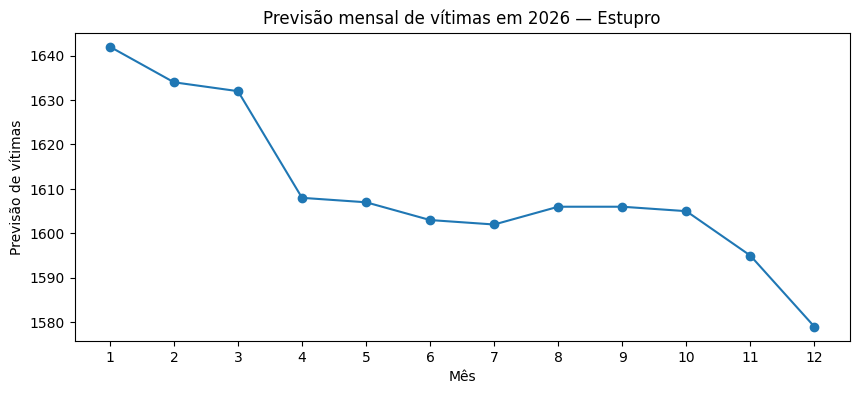

In [39]:
tipo_visualizado = "Estupro"

previsao_tipo_visualizado = dados_futuros_2026[
    dados_futuros_2026["evento"] == tipo_visualizado
]

plt.figure(figsize=(10, 4))
plt.plot(
    previsao_tipo_visualizado["data_mes"],
    previsao_tipo_visualizado["previsao_total_vitima"],
    marker="o"
)
plt.title(f"Previsão mensal de vítimas em 2026 — {tipo_visualizado}")
plt.xlabel("Mês")
plt.ylabel("Previsão de vítimas")
plt.xticks(range(1, 13))
plt.show()

## 12.6 Exportação das previsões

In [40]:
# Salva o resultado final em CSV.
dados_futuros_2026.to_csv(
    "previsao_criminal_2026_brasil.csv",
    index=False,
    encoding="utf-8-sig"
)

# 13. Conclusão

Este MVP teve como objetivo desenvolver modelos de Machine Learning capazes de prever a quantidade mensal de vítimas por tipo criminal no Brasil em 2026, utilizando dados históricos do SINESP referentes ao período de 2020 a 2025.

A base foi preparada a partir da consolidação de arquivos anuais, filtragem dos registros com vítimas e agregação mensal por tipo criminal em nível nacional.

Foram avaliados um baseline temporal e três modelos supervisionados de regressão: Regressão Linear, Floresta Aleatória e Impulsionamento por Gradiente. A avaliação utilizou o ano de 2025 como conjunto de teste, respeitando a ordem temporal dos dados.

O desempenho foi comparado pelas métricas MAE, RMSE e R². O critério principal de sucesso foi superar o baseline em pelo menos 10% na métrica RMSE.

As hipóteses iniciais foram verificadas em seção específica. A Hipótese 1 foi avaliada pelo poder preditivo do melhor modelo; a Hipótese 2 foi analisada pela variação mensal média da variável alvo; e a Hipótese 3 foi verificada pela comparação direta entre o melhor modelo de Machine Learning e o baseline.

As principais limitações do MVP estão relacionadas ao uso de poucas variáveis explicativas, à ausência de dados populacionais, socioeconômicos e regionais, e à escolha de uma modelagem nacional agregada. Como melhorias futuras, recomenda-se explorar previsões por UF, taxas por 100 mil habitantes, variáveis defasadas e modelos específicos de séries temporais.

# 14. Checklist final

- [x] Definição do problema  
- [x] Fonte dos dados  
- [x] Carga direta no notebook  
- [x] Análise exploratória  
- [x] Preparação da base  
- [x] Divisão temporal treino/teste  
- [x] Baseline  
- [x] Modelos candidatos  
- [x] Avaliação inicial  
- [x] Otimização de hiperparâmetros  
- [x] Avaliação final  
- [x] Comprovação das hipóteses  
- [x] Previsão para 2026  
- [x] Discussão de limitações  
- [x] Conclusão